<b> Epsilon - Greedy </b>

<b>Multi-Armed Bandit Problem</b> </br>
This code simulates a classic reinforcement learning problem called the Multi-Armed Bandit. Imagine you're in a casino with 10 slot machines ("arms"). Each machine pays out different average rewards, but you don't know which one is best. Your goal is to figure out the best machine and win as much as possible.
The code tests three different strategies for how often to "explore" (try new machines) vs. "exploit" (stick with the best machine you've found so far). At the end, it draws graphs showing which strategy worked best.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

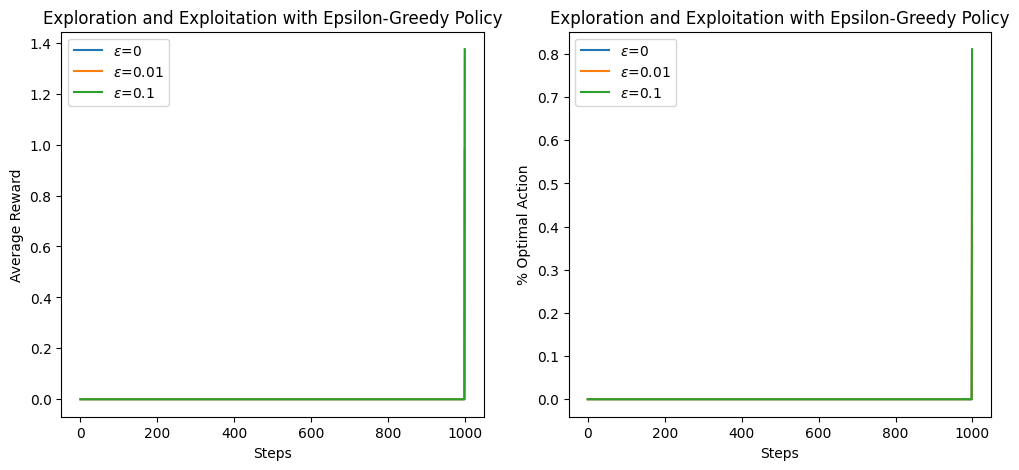

In [14]:
class Bandit:
    def __init__(self, n_arms):  # init is the setup function
        self.n_arms = n_arms
        self.mean = np.random.normal(0, 1, size=n_arms)
        
    def pull_arm(self, arm):  # It returns a random reward centered around the machine's hidden average.
        return np.random.normal(self.mean[arm], 1)
    
#Defining epsilon greedy policy
def egp(Q, epsilon):  # This function will select the next machine for exploring
    '''It picks a random number between 0 and 1
If that number is less than epsilon → Explore: pick a completely random machine (maybe discover something better!)
Otherwise → Exploit: pick the machine with the highest estimated reward so far (np.argmax(Q) finds the index of the highest value)'''
    if np.random.random() < epsilon:
        return np.random.randint(len(Q))
    else:
        return np.argmax(Q)

n_arms = 10  # 10 slot machine
n_steps = 1000  # each experiment runs for 1000 pulls
n_trials = 2000  # The whole experiment is repeated for 2000 times 
epsilons = [0, 0.01, 0.1]  # Different values of epsilon to try
'''0 = never explore (always exploit — pure greed)
0.01 = explore 1% of the time
0.1 = explore 10% of the time'''


# Initialize variables for plotting

# These create two empty score sheets (grids of zeros)
average_rewards = np.zeros((len(epsilons), n_steps))
optimal_action_pct = np.zeros((len(epsilons), n_steps))


# The main loop: Experiment
'''The outer loop goes through each epsilon value (0, 0.01, 0.1)
The inner loop repeats the experiment 2,000 times for that epsilon'''

for i, epsilon in enumerate(epsilons):
    for j in range(n_trials):
        bandit = Bandit(n_arms)
        Q = np.zeros(n_arms)
        N = np.zeros(n_arms)
        total_reward = 0
        optimal_action_count = 0

        for step in range(n_steps):
            action = egp(Q, epsilon)  # decide which machine to pull using the epsilon-greedy strategy
            reward = bandit.pull_arm(action)  # Pull that machine's lever and get a reward
            total_reward += reward # Add that reward to the running total
            N[action] += 1  
            Q[action] += (reward - Q[action]) / N[action]  # Update the estimation by making average
            optimal_action = np.argmax(bandit.mean)  # Peek highest average 
            optimal_action_count += (action == optimal_action)

        # Saving the result
        average_rewards[i][step] += reward / n_trials
        optimal_action_pct[i][step] += (action == optimal_action) / n_trials

# Drawing the graph
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, epsilon in enumerate(epsilons):
    axs[0].plot(average_rewards[i], label="$\epsilon$={}".format(epsilon))
    axs[1].plot(optimal_action_pct[i], label="$\epsilon$={}".format(epsilon))

axs[0].set_xlabel("Steps")
axs[0].set_ylabel("Average Reward")
axs[0].set_title("Exploration and Exploitation with Epsilon-Greedy Policy")
axs[0].legend()

axs[1].set_xlabel("Steps")
axs[1].set_ylabel("% Optimal Action")
axs[1].set_title("Exploration and Exploitation with Epsilon-Greedy Policy")
axs[1].legend()

plt.show()

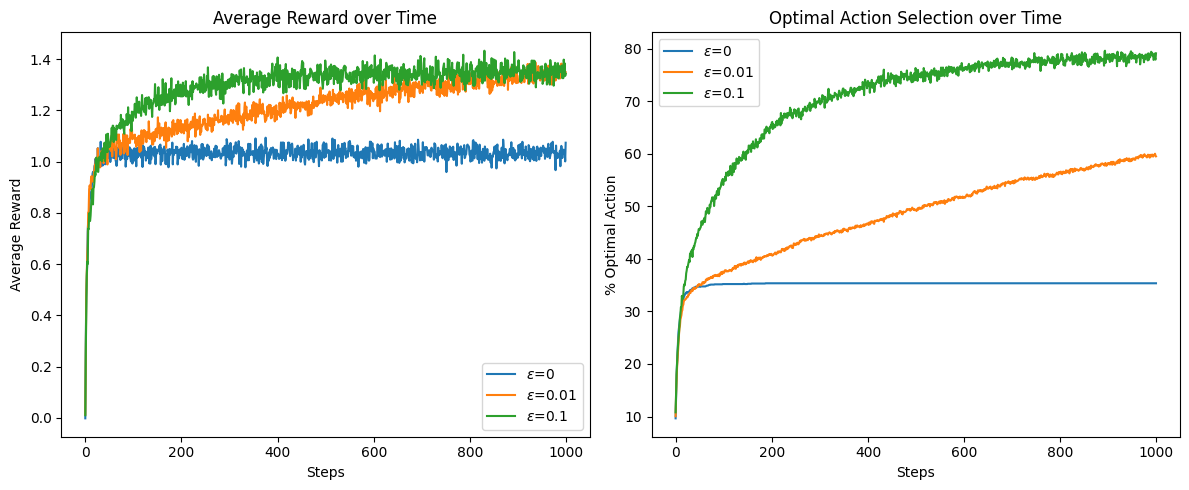

In [21]:
import numpy as np
import matplotlib.pyplot as plt

class Bandit:
    def __init__(self, n_arms): # init is the setup function
        self.n_arms = n_arms
        self.mean = np.random.normal(0, 1, size=n_arms)
        
    def pull_arm(self, arm):  # It returns a random reward centered around the machine's hidden average.
        return np.random.normal(self.mean[arm], 1)

# Defining epsilon greedy policy
'''It picks a random number between 0 and 1
If that number is less than epsilon → Explore: pick a completely random machine (maybe discover something better!)
Otherwise → Exploit: pick the machine with the highest estimated reward so far (np.argmax(Q) finds the index of the highest value)'''

def egp(Q, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(len(Q))
    else:
        return np.argmax(Q)

    

n_arms = 10  # 10 slot machine
n_steps = 1000  # each experiment runs for 1000 pulls
n_trials = 2000  # The whole experiment is repeated for 2000 times 
epsilons = [0, 0.01, 0.1]  # Different values of epsilon to try
'''0 = never explore (always exploit — pure greed)
0.01 = explore 1% of the time
0.1 = explore 10% of the time'''

# Initialize variables for plotting

# These create two empty score sheets (grids of zeros)
average_rewards = np.zeros((len(epsilons), n_steps))
optimal_action_pct = np.zeros((len(epsilons), n_steps))

# The main loop: Experiment
'''The outer loop goes through each epsilon value (0, 0.01, 0.1)
The inner loop repeats the experiment 2,000 times for that epsilon'''
for i, epsilon in enumerate(epsilons):
    for j in range(n_trials):
        bandit = Bandit(n_arms)
        Q = np.zeros(n_arms)
        N = np.zeros(n_arms)

        for step in range(n_steps):
            action = egp(Q, epsilon)   # decide which machine to pull using the epsilon-greedy strategy
            reward = bandit.pull_arm(action)   # Pull that machine's lever and get a reward
            N[action] += 1
            Q[action] += (reward - Q[action]) / N[action]  # Update the estimation by making average

            optimal_action = np.argmax(bandit.mean)  # Peek highest average

            # Save reward and optimal action at EACH STEP, not as a total
            average_rewards[i][step] += reward / n_trials
            optimal_action_pct[i][step] += (action == optimal_action) / n_trials

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, epsilon in enumerate(epsilons):
    axs[0].plot(average_rewards[i], label="$\\epsilon$={}".format(epsilon))
    axs[1].plot(optimal_action_pct[i] * 100, label="$\\epsilon$={}".format(epsilon))

axs[0].set_xlabel("Steps")
axs[0].set_ylabel("Average Reward")
axs[0].set_title("Average Reward over Time")
axs[0].legend()

axs[1].set_xlabel("Steps")
axs[1].set_ylabel("% Optimal Action")
axs[1].set_title("Optimal Action Selection over Time")
axs[1].legend()

plt.tight_layout()
plt.show()